# Norway Future Skills — Data Quality & Labor Market Overview

## Objective

Before analyzing skills, AI-related demand, or regional differences, this notebook checks whether the cleaned Norwegian job-posting dataset is reliable enough for analysis.

The notebook focuses on four questions:

1. What is the size and structure of the dataset?
2. Are there duplicate or incomplete records?
3. What does the geographic distribution of postings look like?
4. Are the occupation and skill fields suitable for later analysis?

## Dataset source

The notebook uses the processed dataset created by:

- `src/collect_nav_jobs.py`
- `src/clean_jobs.py`

Raw job postings were collected from NAV Arbeidsplassen and then cleaned before analysis.

> **Important:** Some missing source values were replaced during preprocessing with explicit placeholders such as `Missing location` and `Not classified`. Therefore, a standard `isna()` check alone does not fully describe data completeness.


In [1]:
# Cell 02 — Load libraries and cleaned job-posting data

import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = "../data/processed/jobs_clean.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
display(df.head())


Dataset shape: 10,000 rows × 12 columns


,job_id,title,company,published,expires,city,occupation,category,skills,has_city,has_occupation,has_skills
0,0112ac82-d16e-449b-8ae0-17e5bb874829,Vil du være med å styrke vår informasjonsforva...,"Informasjonsforvaltning, Lørenskog kommune",2026-08-03T00:00:00+02:00,2026-08-24T00:00:00+02:00,LØRENSKOG,Not classified,Not classified,"Arkiv, Brukerstøtte, Digitalisering, Dokumenta...",True,False,True
1,050bb19a-a9a0-406d-8902-7f211502cd63,Nattsykepleier,"Skien Helsehus, Skien kommune",2026-08-03T00:00:00+02:00,2026-08-31T00:00:00+02:00,SKIEN,Not classified,"Sykepleier, Sykepleier, Sykepleiere","Helsehus, Kommunal helse, Korttidsopphold, Med...",True,False,True
2,0af40df5-b09f-46fb-b6a6-37f943aee756,Nyetablert oppfølgingsteam for barn/familier s...,BUPA Drammen,2026-08-03T00:00:00+02:00,2026-08-23T00:00:00+02:00,DRAMMEN,Not classified,"Psykologspesialist, Psykologspesialist, Psykol...","Ambulant arbeid, Barn, Barne- og ungdomspsykol...",True,False,True
3,0bc718d8-c7ea-4eb0-a9f5-efa112642bd5,Overlege,"Klinikk psykisk helse og avhengighet, BUP Oslo...",2026-08-03T00:00:00+02:00,2026-08-24T00:00:00+02:00,OSLO,Not classified,"Overlege, Overlege, Legespesialister","Barne- og ungdomspsykiatri, Behandling, Lege, ...",True,False,True
4,0c18cc8c-d807-4a6b-bf60-58a91241c2a0,Helsefagarbeider,"Vensmoen 2, Saltdal kommune",2026-08-03T00:00:00+02:00,2026-08-23T00:00:00+02:00,ROGNAN,Not classified,"Helsefagarbeider, Helsefagarbeider, Helsefagar...","Brukermedvirkning, Eldreomsorg, Helse, Helsefa...",True,False,True


## 1. Dataset structure and quality

We first inspect the dataset shape, column types, conventional missing values, and the source-availability flags created during preprocessing.

Because placeholders are used for some missing metadata, both null checks and content-quality checks are needed.


In [2]:
# Cell 04 — Inspect structure, data types, and missingness

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

print("\nData types and non-null counts:")
df.info()

print("\nConventional missing values:")
display(
    df.isna()
      .sum()
      .rename("missing_values")
      .to_frame()
)

availability_columns = [
    col
    for col in ["has_city", "has_occupation", "has_skills"]
    if col in df.columns
]

if availability_columns:
    print("\nSource availability flags:")
    display(
        df[availability_columns]
        .sum()
        .rename("available_records")
        .to_frame()
    )


Rows: 10,000
Columns: 12

Data types and non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   job_id          10000 non-null  str  
 1   title           10000 non-null  str  
 2   company         10000 non-null  str  
 3   published       10000 non-null  str  
 4   expires         10000 non-null  str  
 5   city            10000 non-null  str  
 6   occupation      10000 non-null  str  
 7   category        10000 non-null  str  
 8   skills          10000 non-null  str  
 9   has_city        10000 non-null  bool 
 10  has_occupation  10000 non-null  bool 
 11  has_skills      10000 non-null  bool 
dtypes: bool(3), str(9)
memory usage: 732.6 KB

Conventional missing values:


,missing_values
job_id,0
title,0
company,0
published,0
expires,0
city,0
occupation,0
category,0
skills,0
has_city,0



Source availability flags:


,available_records
has_city,9615
has_occupation,1896
has_skills,9986


### Duplicate check

Duplicate records can distort frequencies and regional comparisons. We therefore check both:

- duplicated full rows
- duplicated `job_id` values

`job_id` should uniquely identify a job posting.


In [3]:
# Cell 06 — Check duplicate rows and duplicate job IDs

duplicate_rows = df.duplicated().sum()
duplicate_job_ids = df["job_id"].duplicated().sum()

print(f"Duplicated full rows: {duplicate_rows}")
print(f"Duplicated job_id values: {duplicate_job_ids}")


Duplicated full rows: 0
Duplicated job_id values: 0


### Data quality summary

The cleaned dataset contains **10,000 job postings and 12 fields**. No conventional null values or duplicate job IDs were found in the current sample.

However, this does **not** mean every field is complete. Missing source metadata is sometimes represented by placeholders rather than `NaN`.

Two limitations are especially important:

- some postings use `Missing location` for unavailable city information
- the occupation field requires a separate content-quality check because non-placeholder values may still be malformed

The dataset is suitable for labor-market and skill analysis, but field-specific limitations must be documented rather than hidden through aggressive deletion.


## 2. Job market overview

### Job-posting distribution by city

Location counts show where postings in this **10,000-job sample** are concentrated.

These counts represent posting volume in the collected sample, not the total size of each local labor market.


In [4]:
# Cell 09 — Inspect the most common city values

city_counts_15 = (
    df["city"]
    .value_counts(dropna=False)
    .head(15)
)

display(city_counts_15)


city
OSLO                1855
TRONDHEIM            417
BERGEN               411
Missing location     385
STAVANGER            285
BODØ                 215
TROMSØ               200
KONGSBERG            141
SANDNES              141
ÅLESUND              138
KRISTIANSAND S       128
DRAMMEN              119
HAUGESUND            101
LØRENSKOG             87
SKIEN                 81
Name: count, dtype: int64

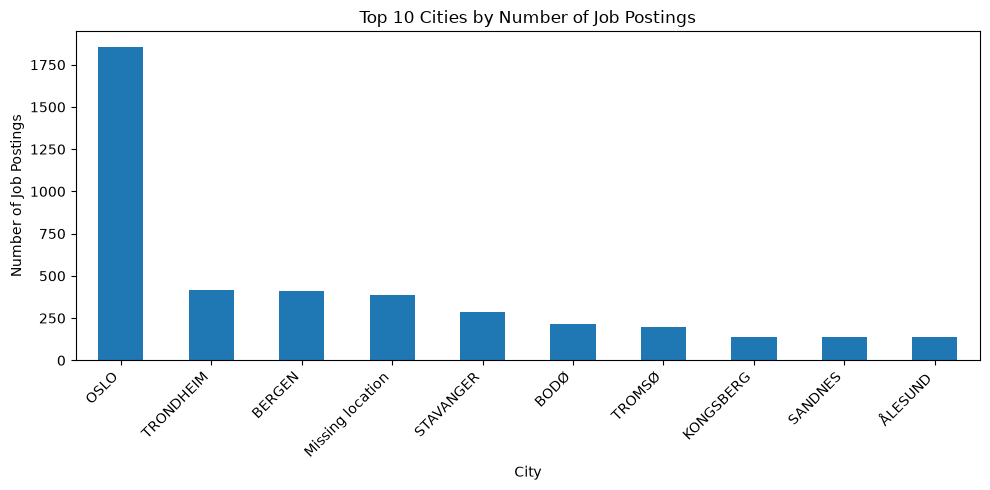

In [5]:
# Cell 10 — Visualize the top 10 cities by job-posting volume

city_counts = (
    df["city"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10, 5))
city_counts.plot(kind="bar")

plt.title("Top 10 Cities by Number of Job Postings")
plt.xlabel("City")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### Interpretation — geographic distribution

In the current sample:

- **Oslo** has the largest number of postings by a wide margin.
- **Trondheim, Bergen, and Stavanger** are also major posting locations.
- Other visible regional markets include **Bodø, Tromsø, Kongsberg, Sandnes, and Ålesund**.
- `Missing location` is one of the more common location values, confirming that some source records lack usable city information.

Missing-location records are retained rather than deleted. Removing them would reduce the dataset and could introduce bias if missingness is not random.

Later geographic analysis should therefore exclude `Missing location` only when comparing named cities, while keeping those jobs in the broader dataset.


In [6]:
# Cell 12 — Save city-level posting counts for later reporting

city_analysis = (
    df["city"]
    .value_counts()
    .rename_axis("city")
    .reset_index(name="job_count")
)

city_analysis.to_csv(
    "../data/processed/city_job_distribution.csv",
    index=False
)

print("Saved: ../data/processed/city_job_distribution.csv")


Saved: ../data/processed/city_job_distribution.csv


## 3. Occupation-field quality

The occupation field cannot be judged only by whether it differs from `Not classified`.

Some extracted occupation values contain only commas and separators, which technically look non-missing but do not contain meaningful occupation information. We therefore check both the source flag and the actual text content.


In [7]:
# Cell 14 — Measure whether occupation values contain usable text

occupation_text = (
    df["occupation"]
    .fillna("")
    .astype(str)
    .str.strip()
)

occupation_non_placeholder = (
    occupation_text.ne("Not classified")
    & occupation_text.ne("")
)

# Remove commas and whitespace to detect delimiter-only values such as "," or ", ,"
occupation_has_meaningful_text = (
    occupation_text
    .str.replace(",", "", regex=False)
    .str.strip()
    .ne("")
)

occupation_usable = (
    occupation_non_placeholder
    & occupation_has_meaningful_text
)

print(f"Total jobs: {len(df):,}")

if "has_occupation" in df.columns:
    print(
        "Source flag has_occupation=True:",
        f"{df['has_occupation'].sum():,}",
        f"({df['has_occupation'].mean():.1%})"
    )

print(
    "Non-placeholder occupation values:",
    f"{occupation_non_placeholder.sum():,}",
    f"({occupation_non_placeholder.mean():.1%})"
)

print(
    "Occupation values with meaningful text:",
    f"{occupation_usable.sum():,}",
    f"({occupation_usable.mean():.1%})"
)


Total jobs: 10,000
Source flag has_occupation=True: 1,896 (19.0%)
Non-placeholder occupation values: 1,896 (19.0%)
Occupation values with meaningful text: 0 (0.0%)


In [8]:
# Cell 15 — Inspect non-placeholder occupation values

occupation_raw_distribution = (
    df.loc[occupation_non_placeholder, "occupation"]
    .value_counts()
    .head(15)
)

display(occupation_raw_distribution)


occupation
,               1469
, ,              315
, , ,             78
, , , ,           22
, , , , ,         10
, , , , , ,        2
Name: count, dtype: int64

### Occupation-field limitation

The source indicates occupation information for a subset of records, but inspection shows that the extracted non-placeholder values are dominated by delimiter-only strings such as `,` and `, ,`.

This means the occupation field is **not reliable enough for primary analysis** in this dataset.

Decision:

- keep the records rather than deleting valid job postings
- do not use `occupation` as a main analytical variable
- rely more on `title`, `category`, `skill`, and `city` in later notebooks
- document the occupation-extraction limitation explicitly

This is an example of an important data-analysis principle: a column can be technically non-null while still being analytically unusable.


## 4. Transform the skills field to long format

The `skills` column stores several comma-separated skills in one string.

For skill analysis, we convert it to a **long-format job–skill table**, where each row represents one skill associated with one job posting.


In [9]:
# Cell 18 — Split and explode the comma-separated skills column

skills_df = df[["job_id", "skills"]].copy()

skills_df["skill"] = (
    skills_df["skills"]
    .str.split(",")
)

skills_df = (
    skills_df
    .explode("skill")
)

skills_df["skill"] = (
    skills_df["skill"]
    .astype(str)
    .str.strip()
)

# Remove empty tokens if any appear after splitting
skills_df = (
    skills_df[
        skills_df["skill"].ne("")
    ]
    .copy()
)

display(skills_df.head())


,job_id,skills,skill
0,0112ac82-d16e-449b-8ae0-17e5bb874829,"Arkiv, Brukerstøtte, Digitalisering, Dokumenta...",Arkiv
0,0112ac82-d16e-449b-8ae0-17e5bb874829,"Arkiv, Brukerstøtte, Digitalisering, Dokumenta...",Brukerstøtte
0,0112ac82-d16e-449b-8ae0-17e5bb874829,"Arkiv, Brukerstøtte, Digitalisering, Dokumenta...",Digitalisering
0,0112ac82-d16e-449b-8ae0-17e5bb874829,"Arkiv, Brukerstøtte, Digitalisering, Dokumenta...",Dokumentasjonsforvaltning
0,0112ac82-d16e-449b-8ae0-17e5bb874829,"Arkiv, Brukerstøtte, Digitalisering, Dokumenta...",Informasjonsforvaltning


In [10]:
# Cell 19 — Inspect the most common observed skills

top_20_skills = (
    skills_df
    .groupby("skill")["job_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(20)
)

display(top_20_skills)


skill
Omsorg                   1471
Kundeservice             1396
Helse                    1106
Butikk                   1057
Salg                      981
Leder                     895
Service                   839
Kontor                    808
Sykepleier                716
Kasse                     636
Butikkmedarbeider         632
Personalansvar            618
Administrasjon            571
Sykehus                   565
Assistent                 543
Veiledning                533
Barn                      519
Tverrfaglig samarbeid     476
Ledelse                   475
Rådgiver                  472
Name: job_id, dtype: int64

In [11]:
# Cell 20 — Validate the exploded job–skill table

empty_skill_count = (
    skills_df["skill"]
    .eq("")
    .sum()
)

duplicate_job_skill_pairs = (
    skills_df[
        ["job_id", "skill"]
    ]
    .duplicated()
    .sum()
)

print(f"Empty skill values: {empty_skill_count}")
print(f"Duplicated job-skill pairs: {duplicate_job_skill_pairs}")


Empty skill values: 0
Duplicated job-skill pairs: 0


## 5. Which skills are most demanded?

Skill demand is measured as the number of **unique job postings** associated with each skill.

Using unique `job_id` values is safer than simply counting rows because it prevents accidental duplicate job–skill relationships from inflating demand.


In [12]:
# Cell 22 — Create the skill-demand frequency table

skill_demand = (
    skills_df
    .groupby("skill")
    .agg(
        job_frequency=("job_id", "nunique")
    )
    .reset_index()
    .sort_values(
        "job_frequency",
        ascending=False
    )
)

display(skill_demand.head(20))


,skill,job_frequency
6217,Omsorg,1471
4801,Kundeservice,1396
3267,Helse,1106
1269,Butikk,1057
7597,Salg,981
5034,Leder,895
7841,Service,839
4533,Kontor,808
8699,Sykepleier,716
4144,Kasse,636


## 6. How many skills are attached to each job?

The number of skills per posting helps us understand the structure of the source data.

This should be interpreted as the number of **observed skill tags in the dataset**, not necessarily the complete number of skills an employer truly requires.


In [13]:
# Cell 24 — Count unique skills per job

job_skill_count = (
    skills_df
    .groupby("job_id")
    .agg(
        number_of_skills=("skill", "nunique")
    )
    .reset_index()
)

display(job_skill_count.head())


,job_id,number_of_skills
0,0008dd66-d1c7-41ae-a911-1d6d0b84e092,10
1,001773d0-923c-4001-bea7-bb53098f5ba6,8
2,001903b6-c738-42b0-b70c-a9d13d1cbc85,10
3,001e12b0-b264-4fc6-9bb7-c9b42ff6dcf4,6
4,0028b108-259b-4554-8439-55bdc19f374e,10


In [14]:
# Cell 25 — Summarize the distribution of skills per job

display(
    job_skill_count["number_of_skills"]
    .describe()
)


count    10000.000000
mean         9.532400
std          0.806979
min          1.000000
25%          9.000000
50%         10.000000
75%         10.000000
max         13.000000
Name: number_of_skills, dtype: float64

In [15]:
# Cell 26 — Count the number of unique observed skills

unique_skill_count = (
    skills_df["skill"]
    .nunique()
)

print(f"Unique observed skills: {unique_skill_count:,}")


Unique observed skills: 10,997


In [16]:
# Cell 27 — Inspect the long tail of rare skills

single_occurrence_skills = (
    skill_demand[
        skill_demand["job_frequency"] == 1
    ]
)

print(
    "Skills appearing in exactly one job:",
    f"{len(single_occurrence_skills):,}"
)

display(
    single_occurrence_skills.head(10)
)


Skills appearing in exactly one job: 5,720


,skill,job_frequency
10996,øvelsesplanlegging,1
2,.net,1
4,12V,1
5,2. linje brukerstøtte,1
10995,økonomiteam,1
10993,økonomisk rådgivning,1
10989,økonomiavdeling,1
10987,økologi,1
42,AIS,1
2941,Førerkort C1,1


In [17]:
# Cell 28 — Inspect the broader skill landscape

display(
    skill_demand.head(50)
)


,skill,job_frequency
6217,Omsorg,1471
4801,Kundeservice,1396
3267,Helse,1106
1269,Butikk,1057
7597,Salg,981
5034,Leder,895
7841,Service,839
4533,Kontor,808
8699,Sykepleier,716
4144,Kasse,636


## 7. Key findings from data-quality EDA

The dataset is suitable for deeper skill analysis, with several important caveats:

- The sample contains **10,000 unique job postings** with no duplicated `job_id` values.
- Standard missing-value checks show no nulls after preprocessing, but explicit placeholders remain and must be interpreted correctly.
- Job postings are geographically concentrated, especially in Oslo, while some records have missing city information.
- The occupation field is not reliable enough for primary analysis because extracted non-placeholder values are largely malformed.
- The skills field can be transformed successfully into a long-format job–skill table.
- Jobs contain roughly **9–10 observed skills on average**, suggesting a fairly standardized skill-tagging structure in the source.
- The skill vocabulary is highly diverse, with **more than 10,000 unique observed skill labels** and a substantial long tail of rare terms.

These findings guide the later notebooks: skill and geographic analysis can proceed, while occupation-based conclusions should be avoided.


In [18]:
# Cell 30 — Save the long-format job–skill table

skills_df.to_csv(
    "../data/processed/job_skills.csv",
    index=False
)

print("Saved: ../data/processed/job_skills.csv")


Saved: ../data/processed/job_skills.csv
